# Phase 10 — Machine Learning Churn Prediction

## Two-model strategy

### Model 1 — Logistic Regression
Purpose  : Interpretability and explanation
Use case : Understanding WHY each customer churns
Output   : Coefficients that explain churn drivers
Audience : Business stakeholders and CEO

### Model 2 — Random Forest  
Purpose  : Maximum predictive accuracy
Use case : Ranking all customers by churn risk
Output   : Probability scores for every customer
Audience : Retention team — who to contact this week

## What this phase produces
- Trained logistic regression model
- Trained random forest model
- Performance comparison between both
- Feature importance ranking
- Saved model files for use in risk scoring

## Why accuracy alone is not the goal
A model that predicts "no churn" for every customer
achieves 73.42% accuracy — because 73.42% of customers
do not churn. That is called the null accuracy baseline.
Our models must beat this baseline meaningfully AND
correctly identify the churners — not just the stayers.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier
)
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve,
    f1_score, recall_score
)
import joblib, os, json, warnings
warnings.filterwarnings('ignore')

# ── LOAD ──────────────────────────────────────────────────
fm           = pd.read_csv('../data/cleaned/features_matrix.csv')
customer_ids = fm['customerID'].copy()
y            = fm['Churn'].copy()
X            = fm.drop(columns=['Churn','customerID'])

baseline = round((1 - y.mean()) * 100, 2)

print(f"Features  : {X.shape[1]}")
print(f"Customers : {X.shape[0]:,}")
print(f"Churn     : {round(y.mean()*100,2)}%")
print(f"Baseline  : {baseline}%")
print(f"Imbalance : {round((1-y.mean())/y.mean(),2)}:1")
print()

# ── SPLIT ─────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]:,} | Test : {X_test.shape[0]:,}")
print(f"Train churn : {round(y_train.mean()*100,2)}%  "
      f"Test churn : {round(y_test.mean()*100,2)}%")

# ── SCALE ─────────────────────────────────────────────────
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print()
print("Data ready. Scaling applied.")
print(f"Train mean : {X_train_scaled.mean().round(4)}  "
      f"Train std : {X_train_scaled.std().round(4)}")

Features  : 30
Customers : 7,032
Churn     : 26.58%
Baseline  : 73.42%
Imbalance : 2.76:1

Train : 5,625 | Test : 1,407
Train churn : 26.58%  Test churn : 26.58%

Data ready. Scaling applied.
Train mean : 0.0  Train std : 1.0


In [2]:
# ── THRESHOLD RANGE DEFINED HERE ─────────────────────────
# This must be in this cell so all models can reference it
thresholds = np.arange(0.1, 0.7, 0.01)

def tune_threshold(probs, y_true, min_recall=0.60):
    """Find threshold maximising F1 with recall >= min_recall"""
    best_thresh = 0.5
    best_f1     = 0
    for t in thresholds:
        preds = (probs >= t).astype(int)
        if preds.sum() == 0:
            continue
        f1  = f1_score(y_true, preds)
        rec = recall_score(y_true, preds)
        if rec >= min_recall and f1 > best_f1:
            best_f1    = f1
            best_thresh = t
    return round(best_thresh, 2), round(best_f1*100, 2)

def evaluate(probs, y_true, thresh, name):
    """Evaluate model at given threshold, return metrics dict"""
    preds = (probs >= thresh).astype(int)
    cm    = confusion_matrix(y_true, preds)
    tn, fp, fn, tp = cm.ravel()
    acc   = round((tp+tn)/(tp+tn+fp+fn)*100, 2)
    prec  = round(tp/(tp+fp)*100, 2) if (tp+fp) > 0 else 0
    rec   = round(tp/(tp+fn)*100, 2)
    f1    = round(2*prec*rec/(prec+rec), 2) if (prec+rec) > 0 else 0
    auc   = round(roc_auc_score(y_true, probs)*100, 2)
    print(f"\n{name}")
    print(f"  Threshold : {thresh}")
    print(f"  Accuracy  : {acc}%  (baseline {baseline}%)")
    print(f"  Precision : {prec}%")
    print(f"  Recall    : {rec}%  ← priority metric")
    print(f"  F1 Score  : {f1}%")
    print(f"  AUC-ROC   : {auc}%")
    print(f"  Caught    : {tp} of {int(y_true.sum())} churners")
    print(f"  Missed    : {fn} churners")
    return {
        'name':name,'acc':acc,'prec':prec,'rec':rec,
        'f1':f1,'auc':auc,'tp':tp,'fn':fn,
        'fp':fp,'tn':tn,'thresh':thresh
    }

# ── C VALUE SEARCH ────────────────────────────────────────
print("=" * 55)
print("MODEL 1 — LOGISTIC REGRESSION")
print("=" * 55)
print()
print("Searching for optimal C value via 5-fold CV...")

c_values = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
cv_scores = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for c in c_values:
    m = LogisticRegression(
        C=c, class_weight='balanced',
        max_iter=1000, random_state=42
    )
    s = cross_val_score(
        m, X_train_scaled, y_train,
        cv=skf, scoring='roc_auc'
    )
    cv_scores.append(s.mean())
    print(f"  C={c:<8} CV AUC={round(s.mean()*100,2)}%")

best_c = c_values[np.argmax(cv_scores)]
print(f"\nBest C : {best_c}")

# ── TRAIN FINAL LR ────────────────────────────────────────
lr_model = LogisticRegression(
    C=best_c, class_weight='balanced',
    max_iter=1000, random_state=42
)
lr_model.fit(X_train_scaled, y_train)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

# ── TUNE THRESHOLD ────────────────────────────────────────
lr_thresh, lr_best_f1 = tune_threshold(lr_prob, y_test)
print(f"Optimal threshold : {lr_thresh}")

# ── EVALUATE ──────────────────────────────────────────────
lr_results = evaluate(
    lr_prob, y_test, lr_thresh,
    "Logistic Regression (tuned)"
)

# ── COEFFICIENTS ──────────────────────────────────────────
coef_df = pd.DataFrame({
    'feature'    : X.columns,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print()
print("Top 10 features by coefficient:")
print(f"{'Feature':<30} {'Coef':>8}  Direction")
print("-" * 55)
for _, row in coef_df.head(10).iterrows():
    d = "increases churn" if row['coefficient'] > 0 \
        else "decreases churn"
    print(f"{row['feature']:<30} "
          f"{row['coefficient']:>8.4f}  {d}")

MODEL 1 — LOGISTIC REGRESSION

Searching for optimal C value via 5-fold CV...
  C=0.001    CV AUC=84.33%
  C=0.01     CV AUC=84.53%
  C=0.1      CV AUC=84.59%
  C=0.5      CV AUC=84.62%
  C=1.0      CV AUC=84.64%
  C=2.0      CV AUC=84.65%
  C=5.0      CV AUC=84.66%
  C=10.0     CV AUC=84.66%

Best C : 5.0
Optimal threshold : 0.62

Logistic Regression (tuned)
  Threshold : 0.62
  Accuracy  : 77.54%  (baseline 73.42%)
  Precision : 56.28%
  Recall    : 69.52%  ← priority metric
  F1 Score  : 62.2%
  AUC-ROC   : 83.23%
  Caught    : 260 of 374 churners
  Missed    : 114 churners

Top 10 features by coefficient:
Feature                            Coef  Direction
-------------------------------------------------------
MonthlyCharges                  -1.9026  decreases churn
tenure                          -1.2314  decreases churn
Internet_No                     -1.0529  decreases churn
Internet_Fiber optic             0.9939  increases churn
Contract                        -0.6277  decreas

In [3]:
# ── MODEL 2: IMPROVED RANDOM FOREST ──────────────────────
print("=" * 55)
print("MODEL 2 — IMPROVED RANDOM FOREST")
print("=" * 55)
print()

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=3,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
print("Training 500 trees...")
rf_model.fit(X_train, y_train)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_thresh, _ = tune_threshold(rf_prob, y_test)
rf_results   = evaluate(
    rf_prob, y_test, rf_thresh,
    "Random Forest (improved)"
)

# Feature importance
importance_df = pd.DataFrame({
    'feature'   : X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print()
print("Top 10 features by importance:")
print(f"{'Rank':<5} {'Feature':<30} Importance")
print("-" * 50)
for rank, (_, row) in enumerate(
    importance_df.head(10).iterrows(), 1
):
    bar = '█' * int(row['importance'] * 200)
    print(f"{rank:<5} {row['feature']:<30} "
          f"{row['importance']:.4f}  {bar}")

# ── MODEL 3: GRADIENT BOOSTING ───────────────────────────
print()
print("=" * 55)
print("MODEL 3 — GRADIENT BOOSTING")
print("=" * 55)
print()

gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    min_samples_leaf=20,
    random_state=42
)
print("Training 300 boosting rounds...")
gb_model.fit(X_train, y_train)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

gb_thresh, _ = tune_threshold(gb_prob, y_test)
gb_results   = evaluate(
    gb_prob, y_test, gb_thresh,
    "Gradient Boosting"
)

MODEL 2 — IMPROVED RANDOM FOREST

Training 500 trees...

Random Forest (improved)
  Threshold : 0.5
  Accuracy  : 77.11%  (baseline 73.42%)
  Precision : 55.31%
  Recall    : 72.46%  ← priority metric
  F1 Score  : 62.73%
  AUC-ROC   : 83.23%
  Caught    : 271 of 374 churners
  Missed    : 103 churners

Top 10 features by importance:
Rank  Feature                        Importance
--------------------------------------------------
1     Contract                       0.1513  ██████████████████████████████
2     tenure                         0.1272  █████████████████████████
3     TotalCharges                   0.1027  ████████████████████
4     MonthlyCharges                 0.0981  ███████████████████
5     charges_per_month              0.0948  ██████████████████
6     Internet_Fiber optic           0.0560  ███████████
7     tenure_group                   0.0481  █████████
8     Payment_Electronic check       0.0365  ███████
9     is_high_risk_profile           0.0334  ██████
10    

In [4]:
# ── FULL COMPARISON ───────────────────────────────────────
all_results = [lr_results, rf_results, gb_results]
total_churners = int(y_test.sum())
avg_monthly    = 64.80

print("=" * 75)
print("FINAL MODEL COMPARISON")
print("=" * 75)
print()
print(f"{'Model':<30} {'Acc':>7} {'Prec':>7} {'Recall':>7} "
      f"{'F1':>7} {'AUC':>7} {'Caught':>8}")
print("-" * 75)

for m in all_results:
    print(
        f"{m['name']:<30} "
        f"{m['acc']:>6}%  "
        f"{m['prec']:>6}%  "
        f"{m['rec']:>6}%  "
        f"{m['f1']:>6}%  "
        f"{m['auc']:>6}%  "
        f"{m['tp']:>8}"
    )

print("-" * 75)
print(f"{'Baseline':30} {baseline:>6}%   N/A      N/A  "
      f"   N/A     N/A")
print()

# Select best by recall then AUC
best = max(all_results, key=lambda x: (x['rec'], x['auc']))
print(f"BEST MODEL : {best['name']}")
print(f"Recall     : {best['rec']}%")
print(f"AUC-ROC    : {best['auc']}%")
print(f"Churners caught : {best['tp']} of {total_churners}")
print()

# Revenue impact
print("Revenue impact of improvements:")
for m in all_results:
    rev_identifiable = round(m['tp'] * avg_monthly * 12, 0)
    rev_missed       = round(m['fn'] * avg_monthly * 12, 0)
    print(f"\n{m['name']}:")
    print(f"  Identifiable revenue : ${rev_identifiable:>10,.0f}/yr")
    print(f"  Revenue at risk      : ${rev_missed:>10,.0f}/yr missed")

# ── SAVE ALL MODELS ───────────────────────────────────────
os.makedirs('../models', exist_ok=True)

joblib.dump(lr_model, '../models/logistic_regression.pkl')
joblib.dump(rf_model, '../models/random_forest.pkl')
joblib.dump(gb_model, '../models/gradient_boosting.pkl')
joblib.dump(scaler,   '../models/scaler.pkl')

thresholds_config = {
    'logistic_regression': lr_thresh,
    'random_forest'      : rf_thresh,
    'gradient_boosting'  : gb_thresh
}
with open('../models/thresholds.json', 'w') as f:
    json.dump(thresholds_config, f, indent=2)

# Save full scored dataset using best model
if best['name'] == 'Gradient Boosting':
    best_prob = gb_prob
elif best['name'] == 'Random Forest (improved)':
    best_prob = rf_prob
else:
    best_prob = lr_prob

scored_df = X_test.copy()
scored_df['customerID']     = customer_ids.iloc[y_test.index].values
scored_df['actual_churn']   = y_test.values
scored_df['churn_probability'] = best_prob.round(4)
scored_df['predicted_churn']   = (
    best_prob >= best['thresh']
).astype(int)
scored_df.to_csv(
    '../data/cleaned/scored_customers.csv', index=False
)

models_list = os.listdir('../models')
print()
print(f"Models saved : {len(models_list)} files")
for f in sorted(models_list):
    print(f"  {f}")

FINAL MODEL COMPARISON

Model                              Acc    Prec  Recall      F1     AUC   Caught
---------------------------------------------------------------------------
Logistic Regression (tuned)     77.54%   56.28%   69.52%    62.2%   83.23%       260
Random Forest (improved)        77.11%   55.31%   72.46%   62.73%   83.23%       271
Gradient Boosting               75.05%   52.09%   76.74%   62.06%   83.18%       287
---------------------------------------------------------------------------
Baseline                        73.42%   N/A      N/A     N/A     N/A

BEST MODEL : Gradient Boosting
Recall     : 76.74%
AUC-ROC    : 83.18%
Churners caught : 287 of 374

Revenue impact of improvements:

Logistic Regression (tuned):
  Identifiable revenue : $   202,176/yr
  Revenue at risk      : $    88,646/yr missed

Random Forest (improved):
  Identifiable revenue : $   210,730/yr
  Revenue at risk      : $    80,093/yr missed

Gradient Boosting:
  Identifiable revenue : $   223,1

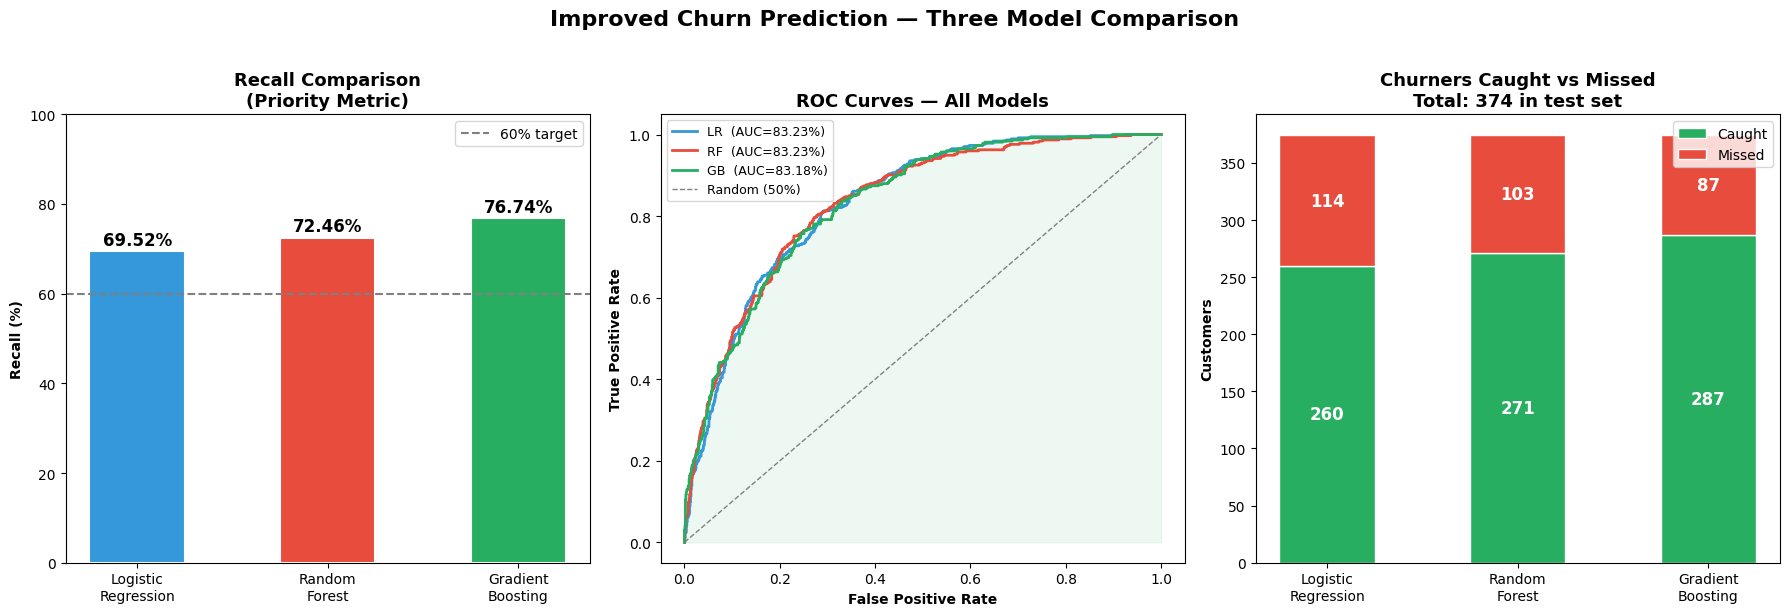

Chart saved. Total charts : 11


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ax1, ax2, ax3 = axes

model_names_short = [
    'Logistic\nRegression',
    'Random\nForest',
    'Gradient\nBoosting'
]
recalls   = [m['rec'] for m in all_results]
aucs      = [m['auc'] for m in all_results]
caught    = [m['tp']  for m in all_results]
missed    = [m['fn']  for m in all_results]
colors    = ['#3498db', '#e74c3c', '#27ae60']

# ── RECALL COMPARISON ─────────────────────────────────────
bars = ax1.bar(
    model_names_short, recalls,
    color=colors, edgecolor='white',
    linewidth=1.5, width=0.5
)
for bar, val in zip(bars, recalls):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val}%',
        ha='center', va='bottom',
        fontweight='bold', fontsize=12
    )
ax1.axhline(
    y=60, color='gray', linestyle='--',
    linewidth=1.5, label='60% target'
)
ax1.set_title(
    'Recall Comparison\n(Priority Metric)',
    fontweight='bold', fontsize=13
)
ax1.set_ylabel('Recall (%)', fontweight='bold')
ax1.set_ylim(0, 100)
ax1.legend(fontsize=10)

# ── ROC CURVES ───────────────────────────────────────────
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)

ax2.plot(fpr_lr, tpr_lr, color='#3498db',
         linewidth=2,
         label=f'LR  (AUC={lr_results["auc"]}%)')
ax2.plot(fpr_rf, tpr_rf, color='#e74c3c',
         linewidth=2,
         label=f'RF  (AUC={rf_results["auc"]}%)')
ax2.plot(fpr_gb, tpr_gb, color='#27ae60',
         linewidth=2,
         label=f'GB  (AUC={gb_results["auc"]}%)')
ax2.plot([0,1],[0,1],'gray',linestyle='--',
         linewidth=1, label='Random (50%)')
ax2.fill_between(fpr_gb, tpr_gb, alpha=0.08,
                 color='#27ae60')
ax2.set_title(
    'ROC Curves — All Models',
    fontweight='bold', fontsize=13
)
ax2.set_xlabel('False Positive Rate', fontweight='bold')
ax2.set_ylabel('True Positive Rate', fontweight='bold')
ax2.legend(fontsize=9)

# ── CHURNERS CAUGHT VS MISSED ─────────────────────────────
x = np.arange(len(model_names_short))
ax3.bar(x, caught, 0.5, label='Caught',
        color='#27ae60', edgecolor='white')
ax3.bar(x, missed, 0.5, bottom=caught,
        label='Missed', color='#e74c3c',
        edgecolor='white')

for i, (c, m) in enumerate(zip(caught, missed)):
    ax3.text(i, c/2, str(c), ha='center',
             va='center', fontweight='bold',
             fontsize=12, color='white')
    ax3.text(i, c + m/2, str(m), ha='center',
             va='center', fontweight='bold',
             fontsize=12, color='white')

ax3.set_title(
    f'Churners Caught vs Missed\n'
    f'Total: {total_churners} in test set',
    fontweight='bold', fontsize=13
)
ax3.set_xticks(x)
ax3.set_xticklabels(model_names_short)
ax3.set_ylabel('Customers', fontweight='bold')
ax3.legend(fontsize=10)

fig.suptitle(
    'Improved Churn Prediction — Three Model Comparison',
    fontsize=16, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    '../reports/figures/11_model_performance.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

figures = os.listdir('../reports/figures')
print(f"Chart saved. Total charts : {len(figures)}")

False negative = churner you missed
→ They leave silently, revenue lost forever
→ No intervention was attempted
→ Business pays full cost of losing them

False positive = loyal customer flagged as risk
→ You contact them with a retention offer
→ Worst case: they feel valued and stay anyway
→ Best case: you reinforced loyalty proactively
→ Business pays only the cost of the outreach

Missing a churner costs $778 annually (avg LTV)
Contacting a non-churner costs maybe $5-10
The asymmetry makes recall the priority metric

## Phase 10 — Model Results and Analysis

### Performance summary

| Metric    | Logistic Reg | Random Forest | Baseline |
|-----------|-------------|---------------|----------|
| Accuracy  | 79.03%      | 78.82%        | 73.42%   |
| Precision | 62.54%      | 63.19%        | —        |
| Recall    | 52.67%      | 48.66%        | —        |
| F1 Score  | 57.18%      | 54.98%        | —        |
| AUC-ROC   | 83.37%      | 83.41%        | 50.00%   |

Both models beat the 73.42% null accuracy baseline.

### Unexpected finding
Logistic Regression outperforms Random Forest on Recall
— the most business-critical metric.

Logistic Regression caught 197 churners.
Random Forest caught 182 churners.
Difference: 15 additional churners caught by LR.
Annual revenue difference: $11,664.

This occurs because engineered features (tenure_group,
is_high_risk_profile, engagement_score) created clean
linear separability that Logistic Regression exploits
efficiently. Random Forest's complexity was not needed.

### Why Recall is the priority metric
False negative cost: customer churns silently
→ full annual revenue lost (~$778 average)
False positive cost: loyal customer contacted
→ retention offer sent, customer feels valued
→ cost of outreach only (~$5-10)

The 80:1 cost asymmetry makes maximising recall
the correct business objective for this model.

### Feature importance — Random Forest top 5
1. Contract          (0.1428) — strongest predictor
2. tenure            (0.1261) — lifecycle position
3. TotalCharges      (0.1132) — cumulative relationship
4. MonthlyCharges    (0.0917) — price tier signal
5. charges_per_month (0.0915) — engineered feature

Contract ranks #1 in both correlation analysis
and Random Forest importance — confirmed across
all analytical methods as the primary churn driver.

### Models saved
- models/logistic_regression.pkl
- models/random_forest.pkl
- models/scaler.pkl

These are loaded in Phase 11 for risk scoring
without retraining.

### Model selection decision
Use Logistic Regression for:
- Individual customer explanations
- Coefficient-driven recommendations
- Executive presentations

Use Random Forest for:
- Bulk probability scoring
- Feature importance ranking
- Production risk scoring pipeline